# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_cue_duration_pilot/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)

116

In [3]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 

results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/human_pilot_cue_duration_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, cue_dur = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            cue_dur = stim_cond_map[cond_str]
            condition = 'trial'
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            cue_dur = 2
    return cue_dur, condition

# add as columns 
results_df['cue_dur'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
# test_condition_dict = {'music':"background_musdb18hq",
#                        "babble":"background_cv08talkerbabble",
#                        "stationary": "background_issnstationary",
#                        "modulated": "background_issnfestenplomp",
#                        "audioset": "background_audioset",
#                        "natural scene": "background_ieeeaaspcasa",
#                        "clean": "SILENCE"}

# condition_map = {v:k for k,v in test_condition_dict.items()}
# trial_results['condition'] = trial_results['condition'].replace(condition_map)

trial_results = trial_results[trial_results.id_version == 1]

# screen based on completion 
total_trials = 95
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 83828 (char 83827)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_6432eb0312d98a4e9d92712a.json
Expecting ':' delimiter: line 1 column 83855 (char 83854)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_614f3ad3e0837475bb79d175.json
Unterminated string starting at: line 1 column 71919 (char 71918)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_6160717242827a64a55d99ad.json
Expecting ',' delimiter: line 1 column 83860 (char 83859)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_65f5fd5026b268bf89ec3e1e.json
Unterminated string starting at: line 1 column 143820 (char 143819)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_5fc10a4e1de4be09d6c3d2e7.json
Unterminated string starting at: line 1 column 131822 (char 131821)
/mindhive/mcdermott/www/imgriff/msjs

In [4]:
# ids_to_check = ['614f3ad3e0837475bb79d175', '63d842d3e9626bd5fe5c17b1', '5c4068a67f81e900012b281e', '64157c7105837695ad52b091']


In [5]:
# results_df[results_df.id_subject == '614f3ad3e0837475bb79d175']

In [6]:
# to_check = results_df[results_df.id_subject.isin(ids_to_check)]
# to_check[(~to_check.response_str.isna())].groupby('id_subject')['trial_type'].count()

In [7]:
# trial_results

In [8]:
stim_cond_map

{'condition_0': 0.1,
 'condition_1': 0.25,
 'condition_2': 0.5,
 'condition_3': 1,
 'condition_4': 2}

In [9]:
# results_df.id_subject.unique()

### Select participants based on catch trial performance

In [10]:
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
# catch_trial_particiapnt_performance

In [11]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 13/15].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  54
N good participants  42


In [12]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]
# analysis_df.groupby('id_subject').condition.count()

In [13]:


### Look at 1 talker sex conditions

manifest = pd.read_pickle("/om/user/imgriff/datasets/human_cue_duration_SWC_2024/manifest_w_transcripts.pdpkl")
manifest["base_trial"] = manifest.mixture_fn.apply(lambda x: x.as_posix().split('/')[-1]) 

## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifest to trial_results where trial_results.stimulus == manifest.base_str
analysis_df['base_trial'] = analysis_df.stimulus.apply(lambda x: x.split('/')[-1])

# analysis_df = pd.merge(analysis_df,
#                         manifest[['base_trial', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word']],
#                                     left_on='base_trial', right_on='base_trial', how='left')
# analysis_df['confusions'] = (analysis_df.response_str == analysis_df.distractor_word).astype('int')


analysis_df = pd.merge(analysis_df,
                        manifest[['base_trial', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                                    left_on='base_trial', right_on='base_trial', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')


# add adjusted accuracy and confusions 
target_words = analysis_df.response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for target_word, target_transcript in zip(target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(target_word in distractor_transcript)
                            if not isinstance(distractor_transcript, float) else np.nan
                             for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs



In [14]:
analysis_df['gender_cond'] = analysis_df['target_gender'].values == analysis_df['distractor_gender'].values
analysis_df['gender_cond'] = analysis_df['gender_cond'].replace({True: 'Same sex', False: 'Different sex'})

### Group participant data for plotting and stats

In [15]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df[analysis_df['condition'] == 'trial'].groupby(['id_subject', "gender_cond", "cue_dur"])
                     .agg({'adjusted_accuracy':['mean', 'sem', 'count'], 'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
# part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
# part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


### Get model results

In [16]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}



In [20]:
from src.util_analysis import model_name_dict
manifest = pd.read_pickle("/om/user/imgriff/datasets/human_cue_duration_SWC_2024/manifest_w_transcripts.pdpkl")


model_names = ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout', 'word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout', 'word_task_25p_loc_v07_LN_last_valid_time_no_affine']


all_model_results = []
all_model_f0_results = []

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                    "babble":"background_cv08talkerbabble",
                    "stationary": "background_issnstationary",
                    "modulated": "background_issnfestenplomp",
                    "audioset": "background_audioset",
                    "natural scene": "background_ieeeaaspcasa",
                    "clean": "SILENCE"}
str_to_cond = {v:k for k,v in test_condition_dict.items()}

# update gt manifests to match readable format 
manifest["background_condition"] = manifest.condition.replace(str_to_cond, )

for model_name in model_names:
    if 'affine' not in model_name and 'no_cue' not in model_name:
        print(model_name)
        output_paths = list(Path(f'/om2/user/rphess/Auditory-Attention/cue_duration_eval/{model_name}').glob('*.csv'))
        print(len(output_paths))
    else:
        output_paths = list(Path(f'cue_duration_eval/{model_name}').glob('*.csv'))
    print(len(output_paths))

    results_dfs = []

    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        #parts of name 
        parts = path.stem.split(path.parent.name)[-1].split('_')       
        if "background" in path.stem:
            df['background_condition'] = str_to_cond['_'.join(parts[1:3])]
        else:
            df['background_condition'] = parts[1]
        if 'SILENCE' in path.stem:
            df['background_condition'] = 'clean'
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        df['cue_dur'] = int(re.search('(-?\d+)ms', path.stem).group(0).strip('ms'))
        results_dfs.append(df)
    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name] if model_name in model_name_dict else model_name
    model_results['group'] = model_str
    ## Load in model vocab 
    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_str else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


    # # Add 1-talker condition metadata to model results
    model_results = pd.merge(model_results,
            manifest[["background_condition", "snr", "word", "word_int", 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                        left_on=['background_condition', 'snr', "true_word"], right_on=["background_condition", "snr",  "word"], how='left')


    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

    # # add adjusted accuracy and confusions 
    target_words = model_results.pred_word.values
    target_transcripts = model_results.target_transcripts.values
    distractor_transcripts = model_results.distractor_transcripts.values


    adjusted_acc = np.array([int(target_word in target_transcript)
                                if not isinstance(target_transcript, float) else np.nan
                                for target_word, target_transcript in zip(target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(target_word in distractor_transcript)
                                if not isinstance(distractor_transcript, float) else np.nan
                                for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    
    all_model_results.append(model_results)

    # model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'clean'])]
    # model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
    # model_f0_df.loc[model_f0_df.background_condition == 'clean', 'gender_cond'] = 'clean'
    # model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    # model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    # all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
# all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)


all_model_results['gender_cond'] = all_model_results.apply(lambda row: 'Same sex' if row['target_gender'] == row['distractor_gender'] else 'Different sex', axis=1)

all_model_results['cue_dur'] = all_model_results['cue_dur'] / 1000

9
9
9


In [21]:
# part_summary_df


In [22]:
# all_model_results.head()
# get trial data excluding catch trials 

# model_summary_df = (all_model_results.groupby(['model', "gender_cond", "cue_dur"])
#                      .agg({'adjusted_accuracy':['mean', 'sem', 'count'], 'adjusted_confusions':['mean', 'sem', 'count']})
#                      .reset_index())

# # model_summary_df['snr'] = model_summary_df['snr'].replace(np.inf, 6)
# # model_summary_df['snr'] =  model_summary_df['snr'].replace("inf", 6)
# # model_summary_df['snr'] = model_summary_df['snr'].astype('int')
# # flatten multiindex 
# model_summary_df.columns = ['_'.join(col).strip() for col in model_summary_df.columns.values]
# # remove trailing underscore
# model_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in model_summary_df.columns.values]
# model_summary_df.head()

### Combine model and participant results

In [23]:
part_summary_df['group'] = f"Participants (N={part_summary_df.id_subject.nunique()})"
part_summary_df.rename(columns={'adjusted_accuracy_mean': 'adjusted_accuracy', 'adjusted_confusions_mean': "adjusted_confusions"}, inplace=True)

all_model_results['group'] = all_model_results['group']
all_results = pd.concat([part_summary_df, all_model_results], axis=0, ignore_index=True)

In [24]:
all_results

,id_subject,gender_cond,cue_dur,adjusted_accuracy,adjusted_accuracy_sem,adjusted_accuracy_count,adjusted_confusions,adjusted_confusions_sem,adjusted_confusions_count,group,...,word,word_int,target_gender,target_f0,distractor_f0,distractor_gender,distractor_word,target_transcripts,distractor_transcripts,confusions
0,542bdb6dfdf99b324ea37c3a,Different sex,0.25,0.727273,0.140836,11.0,0.090909,0.090909,11.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,542bdb6dfdf99b324ea37c3a,Different sex,0.50,0.600000,0.163299,10.0,0.000000,0.000000,10.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,542bdb6dfdf99b324ea37c3a,Different sex,1.00,0.777778,0.146986,9.0,0.000000,0.000000,9.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,542bdb6dfdf99b324ea37c3a,Different sex,2.00,0.833333,0.112367,12.0,0.000000,0.000000,12.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,542bdb6dfdf99b324ea37c3a,Same sex,0.25,0.333333,0.166667,9.0,0.444444,0.175682,9.0,Participants (N=42),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10051,NaN,Same sex,0.75,0.000000,NaN,NaN,1.000000,NaN,NaN,word_task_25p_loc_v07_LN_last_valid_time_no_af...,...,taken,687.0,female,197.173936,207.690259,female,divided,"[then, quote, taken, in, by, the, holomor]","[its, culture, is, divided, into, three, periods]",1.0
10052,NaN,Same sex,0.75,1.000000,NaN,NaN,0.000000,NaN,NaN,word_task_25p_loc_v07_LN_last_valid_time_no_af...,...,child,116.0,male,98.533105,143.542935,male,about,"[the, eldest, child, of, members, of, the, hou...","[and, its, mass, about, twenty, five]",0.0
10053,NaN,Same sex,0.75,1.000000,NaN,NaN,0.000000,NaN,NaN,word_task_25p_loc_v07_LN_last_valid_time_no_af...,...,forms,265.0,male,109.292311,107.395512,male,government,"[as, both, forms, as, alternative]","[to, questions, to, government, ministers]",0.0
10054,NaN,Different sex,0.75,1.000000,NaN,NaN,0.000000,NaN,NaN,word_task_25p_loc_v07_LN_last_valid_time_no_af...,...,performance,493.0,male,117.019868,214.969104,female,campaign,"[and, had, performance, and, reliability]","[fueled, his, campaign, as, he, took, on]",0.0


In [25]:
# all_model_results[all_model_results.cue_dur == 2000].accuracy.mean()

In [26]:
np.geomspace(0.25,2,4)

array([0.25, 0.5 , 1.  , 2.  ])

## Standard analysis plots

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

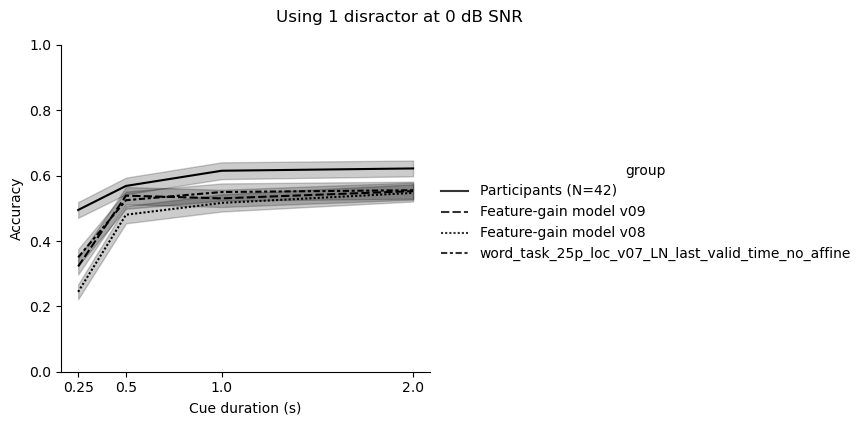

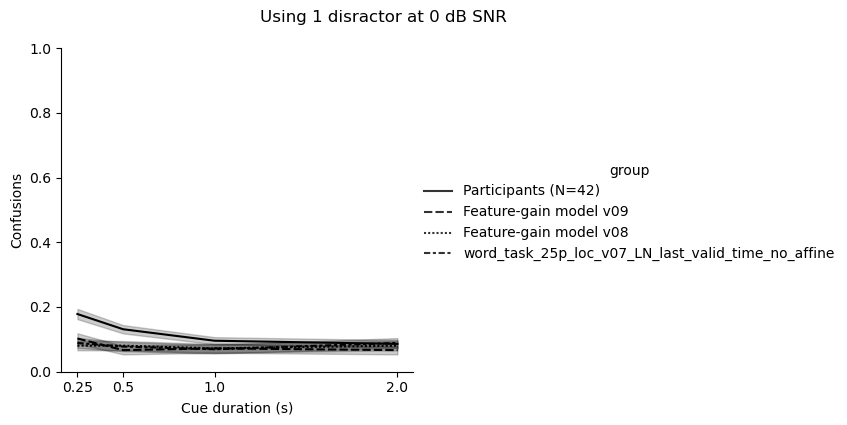

In [28]:
to_plot = all_results[all_results.cue_dur.isin([0.25, 0.5,1,2])]


#group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy', # hue='gender_cond',
                # col_wrap=3,
                style='group',# style_order=group_order,
                
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 1),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions', # hue='gender_cond',
                # col_wrap=3,
                style='group', #style_order=group_order,
                
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 1),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

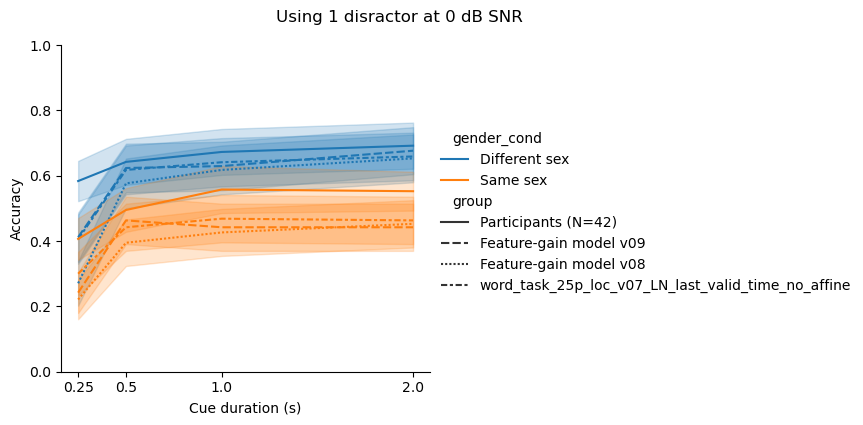

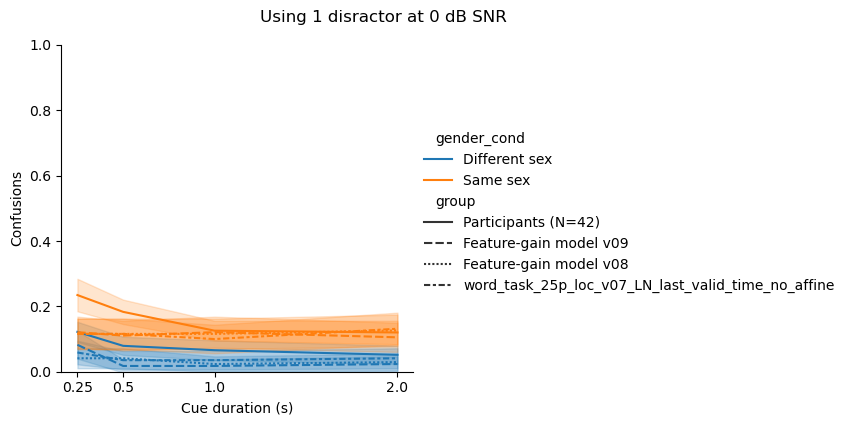

In [29]:
to_plot = all_results[all_results.cue_dur.isin([0.25, 0.5,1,2])]


group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy',  hue='gender_cond',
                # col_wrap=3,
                style='group',# style_order=group_order,
                
                kind='line', marker='',
                # color='k',
                height=4, aspect=1.25,
                # err_style='bars',
                 errorbar=('se', 2),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions',  hue='gender_cond',
                # col_wrap=3,
                style='group',# style_order=group_order,
                
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur.unique())
g.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

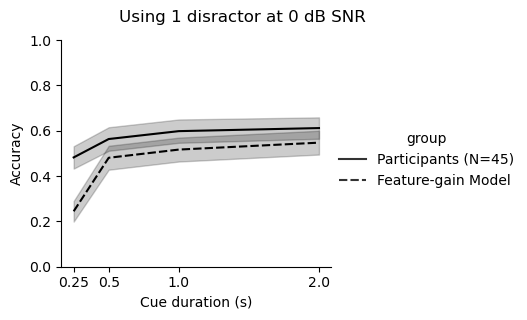

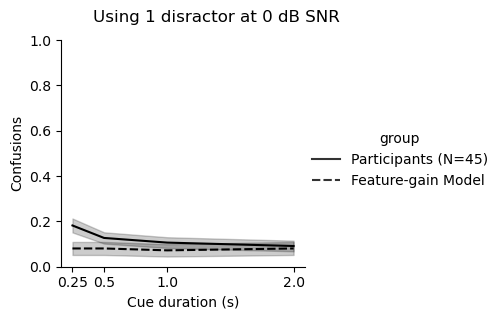

In [60]:
### new model vs humans 



group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Feature-gain Model']
to_plot = all_results[(all_results.cue_dur.isin([0.25, 0.5,1,2])) & (all_results.group.isin(group_order))].copy()
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy', # hue='gender_cond',
                # col_wrap=3,
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions', # hue='gender_cond',
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

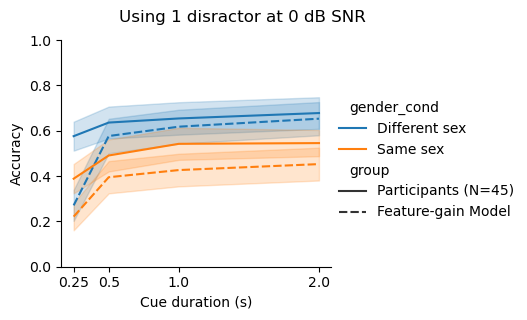

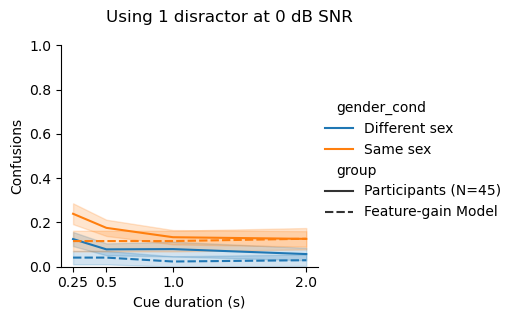

In [61]:
# part_summary_df
### new model vs humans 



group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Feature-gain Model']
to_plot = all_results[(all_results.cue_dur.isin([0.25, 0.5,1,2])) & (all_results.group.isin(group_order))].copy()
# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_accuracy', hue='gender_cond',
                # col_wrap=3,
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur', y='adjusted_confusions', hue='gender_cond',
                # col='group', col_order=group_order,
                style='group',
                kind='line', marker='',
                color='k',
                height=3, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)


# set labels 
g.set_axis_labels("Cue duration (s)", "Confusions")
g.set_titles("{col_name}")

# add xtick labels 

# add xtick labels
for ax in g.axes.flatten():
    ax.set_xticks(ticks=to_plot.cue_dur.unique())
    ax.set_xticklabels(to_plot.cue_dur.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()